# 2. Baseline Model

**Course:** TC5035.10 - Capstone project
**Tecnológico de Monterrey**

**Professor:** Raúl Valente Ramírez Velarde

---
**Team:** 57
> César Miguel Barrientos Robles - A01796615
>
> Alan Julian Rodríguez García - A01796833

## Context

This notebook builds a **baseline model** for the LSM (Lengua de Señas Mexicana) static hand sign classification problem. The goal is to establish a reference point that:

1. Validates that the extracted MediaPipe keypoints contain sufficient signal to distinguish between the 26 LSM letters.
2. Sets a **minimum acceptable performance** threshold against which more complex models (e.g., the LSMTransformer) can be compared.
3. Identifies the most discriminative features and detects potential overfitting/underfitting issues early.

**Approach:** We use a **Random Forest classifier** as the primary baseline — it handles multicollinearity well, provides built-in feature importance, and requires minimal hyperparameter tuning. We also include a **Logistic Regression** as a linear reference and a **Dummy classifier** to establish the random-chance floor.

## 1. Setup and Data Loading

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import learning_curve, cross_val_score

from manos_hablando.dataset import load_keypoints, normalize_keypoints, split_dataset

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

2026-05-25 21:26:01.737 | INFO     | manos_hablando.config:<module>:11 - PROJ_ROOT path is: /Users/cbarrien/Documents/Projects/Personal/LSM/manos-hablando


In [2]:
# Load, normalize, and split the dataset using the project's pipeline
X, y, encoder = load_keypoints()
X = normalize_keypoints(X)
X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(X, y)

class_names = list(encoder.classes_)
n_classes = len(class_names)

print(f"Features per sample: {X_train.shape[1]}")
print(f"Number of classes:   {n_classes}")
print(f"Classes:             {class_names}")
print(f"\nSplit sizes:")
print(f"  Train: {X_train.shape[0]:,}")
print(f"  Val:   {X_val.shape[0]:,}")
print(f"  Test:  {X_test.shape[0]:,}")

2026-05-25 21:26:02.562 | INFO     | manos_hablando.dataset:load_keypoints:32 - Loaded 2057 samples from /Users/cbarrien/Documents/Projects/Personal/LSM/manos-hablando/data/processed/keypoints.json


Loading keypoints: 100%|██████████| 2057/2057 [00:00<00:00, 211784.66it/s]

2026-05-25 21:26:02.586 | INFO     | manos_hablando.dataset:load_keypoints:48 - Classes (26): [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('H'), np.str_('I'), np.str_('K'), np.str_('L'), np.str_('LL'), np.str_('M'), np.str_('N'), np.str_('O'), np.str_('P'), np.str_('Q'), np.str_('R'), np.str_('RR'), np.str_('S'), np.str_('T'), np.str_('U'), np.str_('V'), np.str_('W'), np.str_('X'), np.str_('Y')]
2026-05-25 21:26:02.586 | INFO     | manos_hablando.dataset:load_keypoints:49 - X shape: (2057, 63)
2026-05-25 21:26:02.586 | INFO     | manos_hablando.dataset:load_keypoints:50 - y shape: (2057,)
2026-05-25 21:26:02.592 | INFO     | manos_hablando.dataset:split_dataset:116 - Train: 1439 samples
2026-05-25 21:26:02.593 | INFO     | manos_hablando.dataset:split_dataset:117 - Val:   309 samples
2026-05-25 21:26:02.593 | INFO     | manos_hablando.dataset:split_dataset:118 - Test:  309 samples
Features per sample: 63
Number of classes:  

## 2. Metric Selection

### ¿Cuál es la métrica adecuada para este problema de negocio?

For a 26-class sign language recognition system, we use two primary metrics:

| Metric | Rationale |
|--------|-----------|
| **Accuracy** | With balanced classes (~79-100 samples each), accuracy is a valid overall measure. A random classifier would achieve ~3.8% (1/26). |
| **Macro F1-score** | Treats all 26 letters equally regardless of frequency. This is critical because every letter matters for communication — misclassifying a rare letter is just as costly as misclassifying a common one. |

We also examine the **confusion matrix** to identify specific letter pairs that are easily confused (e.g., letters with similar hand shapes).

### ¿Cuál debería ser el desempeño mínimo a obtener?

- **Random chance:** 1/26 ≈ **3.8%** accuracy
- **Minimum acceptable baseline:** **≥ 50% accuracy** — substantially above chance, demonstrating that the keypoints encode meaningful sign information
- **Target for production:** **≥ 85% accuracy** — necessary for a usable real-time translation tool
- **Current Transformer model:** ~78.6% test accuracy (already trained, serves as an upper reference for now)

## 3. Baseline Models

### ¿Qué algoritmo se puede utilizar como baseline para predecir las variables objetivo?

We train three models to establish a performance spectrum:

1. **DummyClassifier (stratified):** Predicts based on class frequency — the random-chance floor.
2. **Logistic Regression:** A simple linear model. If it performs well, the problem has linearly separable structure.
3. **Random Forest (100 trees):** A non-linear ensemble that captures feature interactions without extensive tuning. This is our **primary baseline**.

In [3]:
# Define baseline models
models = {
    "Dummy (stratified)": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
}

# Train and evaluate each model
results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    y_pred_test = model.predict(X_test)

    row = {
        "Model": name,
        "Train Acc": accuracy_score(y_train, y_pred_train),
        "Val Acc": accuracy_score(y_val, y_pred_val),
        "Test Acc": accuracy_score(y_test, y_pred_test),
        "Train F1 (macro)": f1_score(y_train, y_pred_train, average="macro"),
        "Val F1 (macro)": f1_score(y_val, y_pred_val, average="macro"),
        "Test F1 (macro)": f1_score(y_test, y_pred_test, average="macro"),
    }
    results.append(row)
    print(f"✓ {name} trained")

results_df = pd.DataFrame(results).set_index("Model")
display(results_df.style.format("{:.4f}").background_gradient(cmap="Greens", axis=None))

✓ Dummy (stratified) trained
✓ Logistic Regression trained
✓ Random Forest trained


,Train Acc,Val Acc,Test Acc,Train F1 (macro),Val F1 (macro),Test F1 (macro)
Model,,,,,,
Dummy (stratified),0.0361,0.0485,0.0485,0.0354,0.0464,0.0477
Logistic Regression,0.5942,0.5405,0.5113,0.5515,0.4810,0.4751
Random Forest,1.0000,0.7540,0.7670,1.0000,0.7272,0.7511


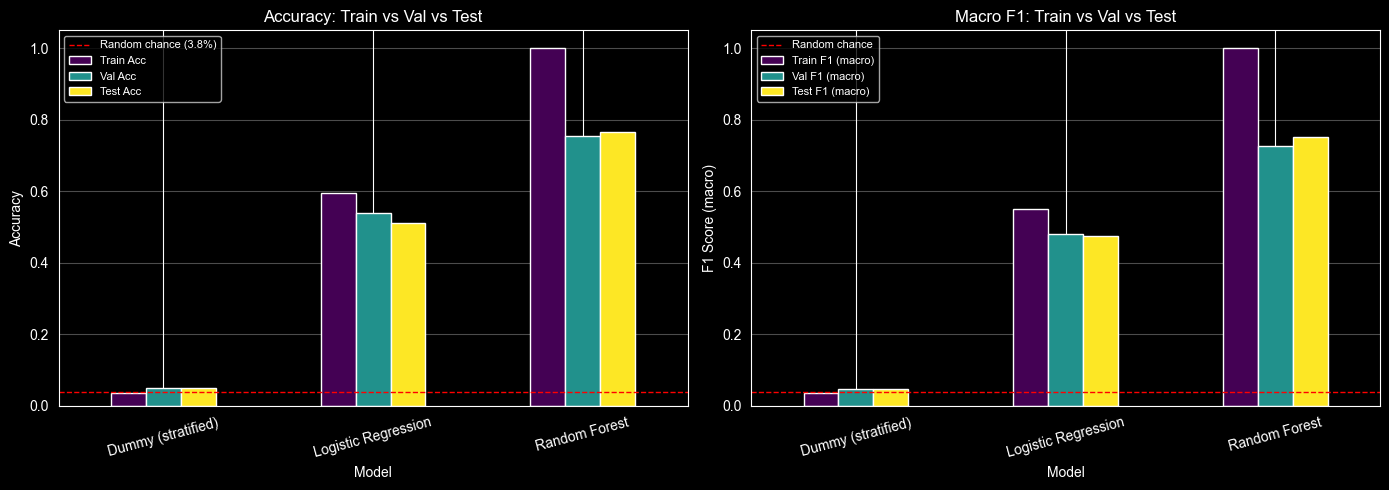

In [4]:
# Visual comparison of model performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
metrics_acc = results_df[["Train Acc", "Val Acc", "Test Acc"]]
metrics_acc.plot(kind="bar", ax=axes[0], rot=15, colormap="viridis")
axes[0].set_title("Accuracy: Train vs Val vs Test")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1.05)
axes[0].axhline(y=1/n_classes, color="red", linestyle="--", linewidth=1, label=f"Random chance ({1/n_classes:.1%})")
axes[0].legend(fontsize=8)
axes[0].grid(axis="y", alpha=0.3)

# F1 comparison
metrics_f1 = results_df[["Train F1 (macro)", "Val F1 (macro)", "Test F1 (macro)"]]
metrics_f1.plot(kind="bar", ax=axes[1], rot=15, colormap="viridis")
axes[1].set_title("Macro F1: Train vs Val vs Test")
axes[1].set_ylabel("F1 Score (macro)")
axes[1].set_ylim(0, 1.05)
axes[1].axhline(y=1/n_classes, color="red", linestyle="--", linewidth=1, label=f"Random chance")
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Detailed Evaluation of the Primary Baseline (Random Forest)

### 4.1 Classification Report (per-class metrics)

In [5]:
# Per-class classification report on the test set
rf_model = trained_models["Random Forest"]
y_pred_test = rf_model.predict(X_test)

print("Classification Report — Random Forest (Test Set)")
print("=" * 60)
print(classification_report(y_test, y_pred_test, target_names=class_names, digits=3))

Classification Report — Random Forest (Test Set)
              precision    recall  f1-score   support

           A      0.615     0.727     0.667        11
           B      0.900     1.000     0.947         9
           C      0.800     0.571     0.667         7
           D      0.800     0.571     0.667         7
           E      0.778     1.000     0.875        14
           F      0.909     0.833     0.870        12
           G      0.818     0.643     0.720        14
           H      0.600     0.923     0.727        13
           I      1.000     0.769     0.870        13
           K      0.750     0.750     0.750        12
           L      0.727     0.667     0.696        12
          LL      0.765     0.929     0.839        14
           M      0.769     0.909     0.833        11
           N      0.500     0.400     0.444        10
           O      0.824     1.000     0.903        14
           P      0.600     0.500     0.545        12
           Q      0.750     0.37

### 4.2 Confusion Matrix

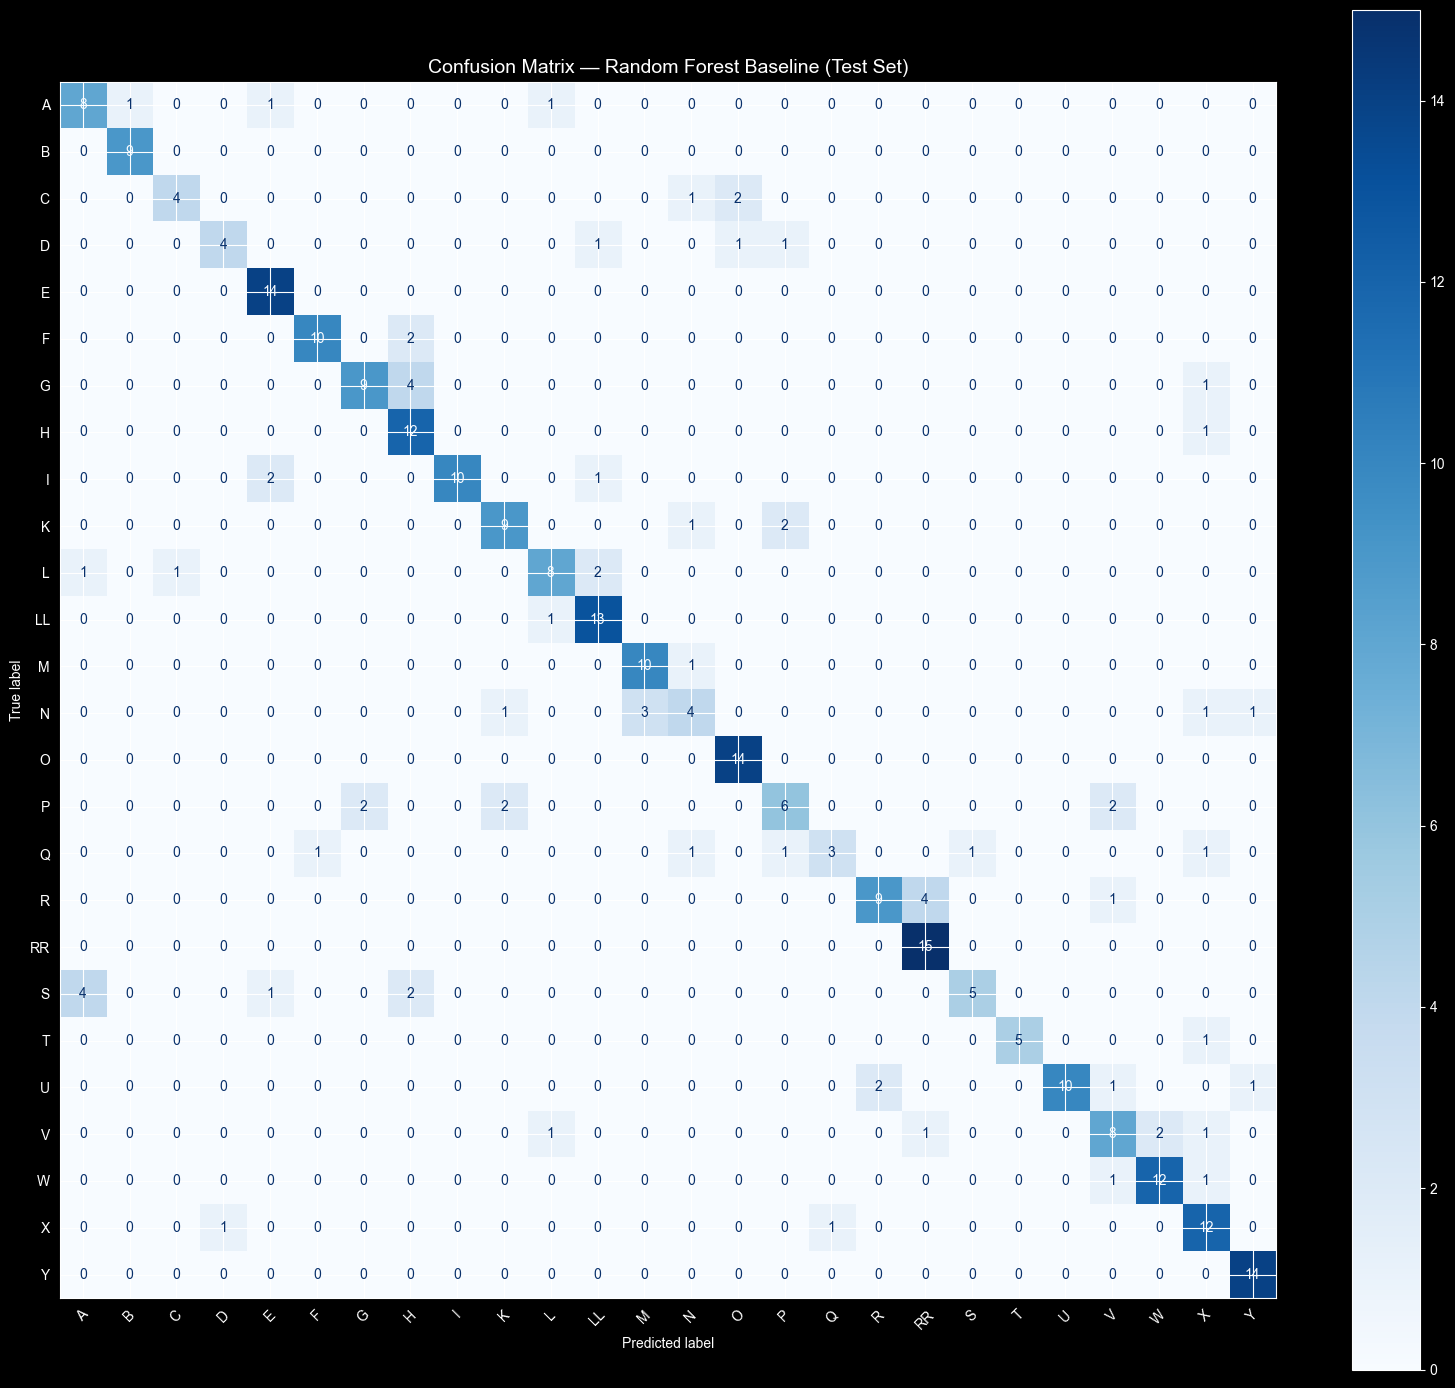


Top 10 most confused letter pairs (true → predicted, count):
  G → H: 4
  R → RR: 4
  S → A: 4
  N → M: 3
  C → O: 2
  F → H: 2
  I → E: 2
  K → P: 2
  L → LL: 2
  P → G: 2


In [6]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

fig, ax = plt.subplots(figsize=(16, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", values_format="d", xticks_rotation=45)
ax.set_title("Confusion Matrix — Random Forest Baseline (Test Set)", fontsize=14)
plt.tight_layout()
plt.show()

# Identify the most confused letter pairs
cm_off_diag = cm.copy()
np.fill_diagonal(cm_off_diag, 0)
top_confusions = []
for i in range(n_classes):
    for j in range(n_classes):
        if cm_off_diag[i, j] > 0:
            top_confusions.append((class_names[i], class_names[j], cm_off_diag[i, j]))

top_confusions.sort(key=lambda x: x[2], reverse=True)
print("\nTop 10 most confused letter pairs (true → predicted, count):")
for true_l, pred_l, count in top_confusions[:10]:
    print(f"  {true_l} → {pred_l}: {count}")

## 5. Feature Importance

### ¿Se puede determinar la importancia de las características para el modelo generado?

Random Forest provides a natural measure of feature importance via **Mean Decrease in Impurity (MDI)** — features that produce the largest reduction in Gini impurity across all trees are the most discriminative for classifying letters.

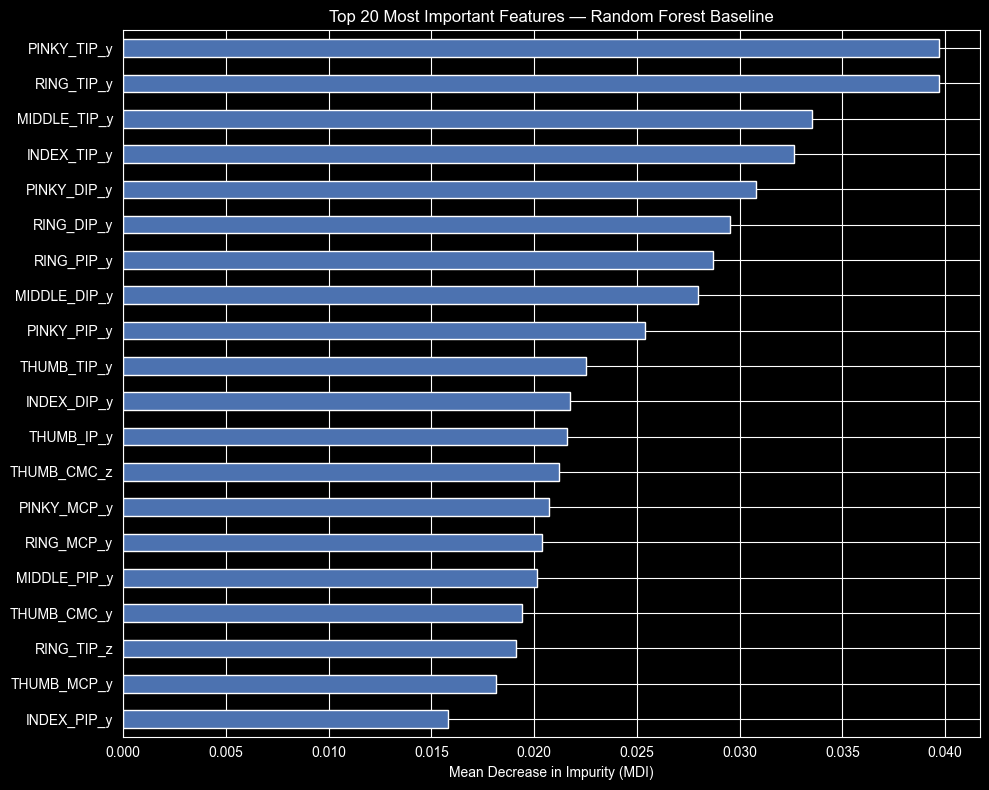


Top 20 features account for 50.9% of total importance
Bottom 20 features account for 17.7% of total importance


In [7]:
# Build feature names for the 63 normalized keypoint coordinates
LANDMARK_NAMES = [
    "WRIST",
    "THUMB_CMC", "THUMB_MCP", "THUMB_IP", "THUMB_TIP",
    "INDEX_MCP", "INDEX_PIP", "INDEX_DIP", "INDEX_TIP",
    "MIDDLE_MCP", "MIDDLE_PIP", "MIDDLE_DIP", "MIDDLE_TIP",
    "RING_MCP", "RING_PIP", "RING_DIP", "RING_TIP",
    "PINKY_MCP", "PINKY_PIP", "PINKY_DIP", "PINKY_TIP",
]
feature_names = [f"{name}_{c}" for name in LANDMARK_NAMES for c in ["x", "y", "z"]]

# Extract and sort importances
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Top 20 features
fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.head(20).plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("Mean Decrease in Impurity (MDI)")
ax.set_title("Top 20 Most Important Features — Random Forest Baseline")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nTop 20 features account for {feat_imp.head(20).sum():.1%} of total importance")
print(f"Bottom 20 features account for {feat_imp.tail(20).sum():.1%} of total importance")

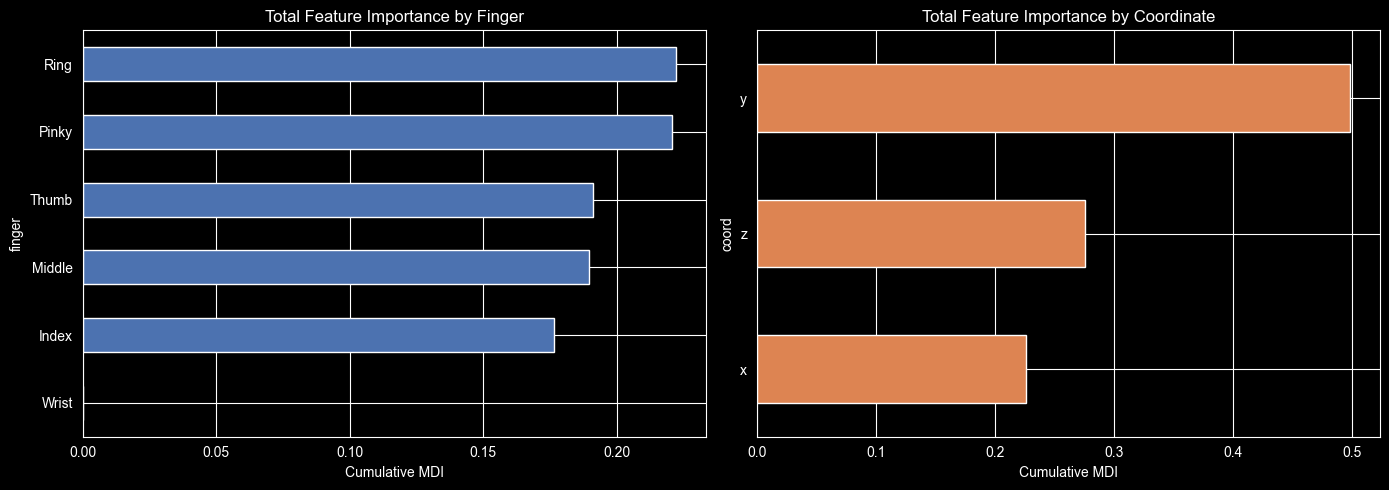

In [8]:
# Feature importance grouped by finger and coordinate type
finger_map = {
    "WRIST": "Wrist",
    "THUMB_CMC": "Thumb", "THUMB_MCP": "Thumb", "THUMB_IP": "Thumb", "THUMB_TIP": "Thumb",
    "INDEX_MCP": "Index", "INDEX_PIP": "Index", "INDEX_DIP": "Index", "INDEX_TIP": "Index",
    "MIDDLE_MCP": "Middle", "MIDDLE_PIP": "Middle", "MIDDLE_DIP": "Middle", "MIDDLE_TIP": "Middle",
    "RING_MCP": "Ring", "RING_PIP": "Ring", "RING_DIP": "Ring", "RING_TIP": "Ring",
    "PINKY_MCP": "Pinky", "PINKY_PIP": "Pinky", "PINKY_DIP": "Pinky", "PINKY_TIP": "Pinky",
}

imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
imp_df["landmark"] = imp_df["feature"].apply(lambda x: "_".join(x.split("_")[:-1]))
imp_df["finger"] = imp_df["landmark"].map(finger_map)
imp_df["coord"] = imp_df["feature"].apply(lambda x: x.split("_")[-1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By finger
imp_df.groupby("finger")["importance"].sum().sort_values().plot(
    kind="barh", ax=axes[0], color="#4C72B0"
)
axes[0].set_title("Total Feature Importance by Finger")
axes[0].set_xlabel("Cumulative MDI")

# By coordinate type
imp_df.groupby("coord")["importance"].sum().sort_values().plot(
    kind="barh", ax=axes[1], color="#DD8452"
)
axes[1].set_title("Total Feature Importance by Coordinate")
axes[1].set_xlabel("Cumulative MDI")

plt.tight_layout()
plt.show()

## 6. Overfitting / Underfitting Analysis

### ¿El modelo está sub/sobreajustando los datos de entrenamiento?

We use **learning curves** to diagnose whether the model suffers from:
- **Underfitting (high bias):** Both train and validation scores are low — the model is too simple.
- **Overfitting (high variance):** Train score is high but validation score is significantly lower — the model memorizes training data.

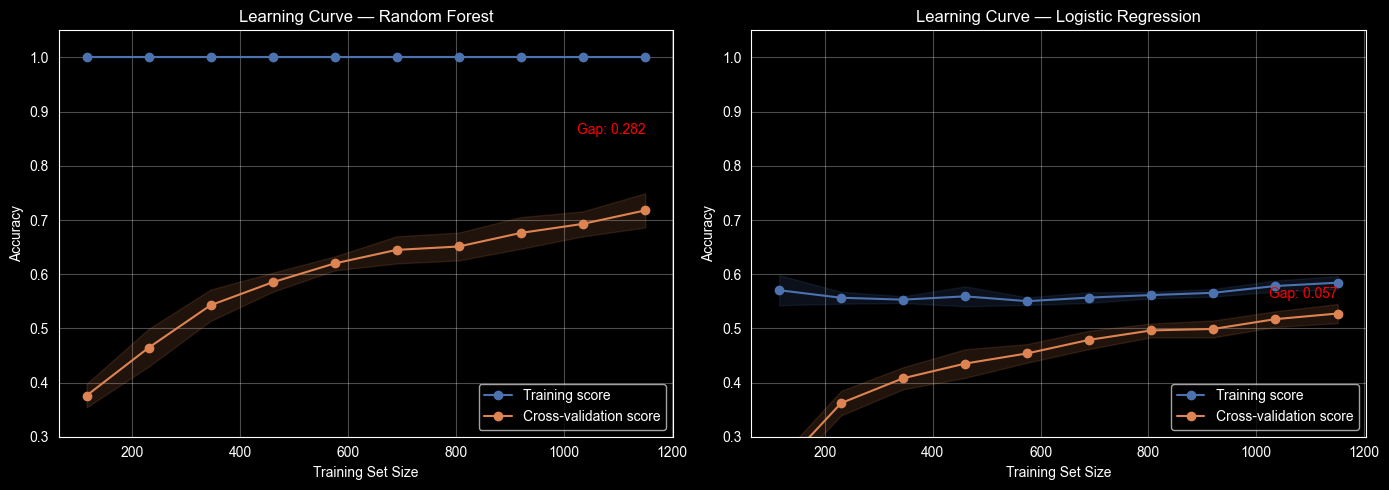

In [9]:
# Learning curves for Random Forest and Logistic Regression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, [
    ("Random Forest", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
]):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_train, y_train,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=5,
        scoring="accuracy",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color="#4C72B0")
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color="#DD8452")
    ax.plot(train_sizes, train_mean, "o-", color="#4C72B0", label="Training score")
    ax.plot(train_sizes, val_mean, "o-", color="#DD8452", label="Cross-validation score")

    ax.set_title(f"Learning Curve — {name}")
    ax.set_xlabel("Training Set Size")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.3, 1.05)
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)

    # Annotate the gap
    gap = train_mean[-1] - val_mean[-1]
    ax.annotate(
        f"Gap: {gap:.3f}",
        xy=(train_sizes[-1], (train_mean[-1] + val_mean[-1]) / 2),
        fontsize=10, ha="right", color="red",
    )

plt.tight_layout()
plt.show()

In [10]:
# Cross-validation scores to quantify generalization
print("5-Fold Cross-Validation on Training Set")
print("=" * 50)

for name in ["Logistic Regression", "Random Forest"]:
    model_class = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    }[name]

    cv_acc = cross_val_score(model_class, X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1)
    cv_f1 = cross_val_score(model_class, X_train, y_train, cv=5, scoring="f1_macro", n_jobs=-1)

    print(f"\n{name}:")
    print(f"  Accuracy: {cv_acc.mean():.4f} ± {cv_acc.std():.4f}")
    print(f"  F1 macro: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

5-Fold Cross-Validation on Training Set

Logistic Regression:
  Accuracy: 0.5268 ± 0.0178
  F1 macro: 0.4803 ± 0.0148

Random Forest:
  Accuracy: 0.7192 ± 0.0305
  F1 macro: 0.6850 ± 0.0299


### 6.1 Train vs Test Gap Analysis

In [11]:
# Summarize overfitting/underfitting diagnosis
print("Overfitting / Underfitting Diagnosis")
print("=" * 50)

for name in ["Logistic Regression", "Random Forest"]:
    model = trained_models[name]
    train_acc = accuracy_score(y_train, model.predict(X_train))
    val_acc = accuracy_score(y_val, model.predict(X_val))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    gap_train_val = train_acc - val_acc
    gap_train_test = train_acc - test_acc

    print(f"\n{name}:")
    print(f"  Train Acc:      {train_acc:.4f}")
    print(f"  Val Acc:        {val_acc:.4f}")
    print(f"  Test Acc:       {test_acc:.4f}")
    print(f"  Train-Val Gap:  {gap_train_val:.4f}")
    print(f"  Train-Test Gap: {gap_train_test:.4f}")

    if train_acc > 0.95 and gap_train_val > 0.15:
        print(f"  → OVERFITTING: high train accuracy with large generalization gap")
    elif val_acc < 0.40:
        print(f"  → UNDERFITTING: validation accuracy too low")
    elif gap_train_val > 0.10:
        print(f"  → MODERATE OVERFITTING: consider regularization or more data")
    else:
        print(f"  → GOOD FIT: reasonable train-val gap")

Overfitting / Underfitting Diagnosis

Logistic Regression:
  Train Acc:      0.5942
  Val Acc:        0.5405
  Test Acc:       0.5113
  Train-Val Gap:  0.0537
  Train-Test Gap: 0.0828
  → GOOD FIT: reasonable train-val gap

Random Forest:
  Train Acc:      1.0000
  Val Acc:        0.7540
  Test Acc:       0.7670
  Train-Val Gap:  0.2460
  Train-Test Gap: 0.2330
  → OVERFITTING: high train accuracy with large generalization gap


## 7. Per-Class Performance Analysis

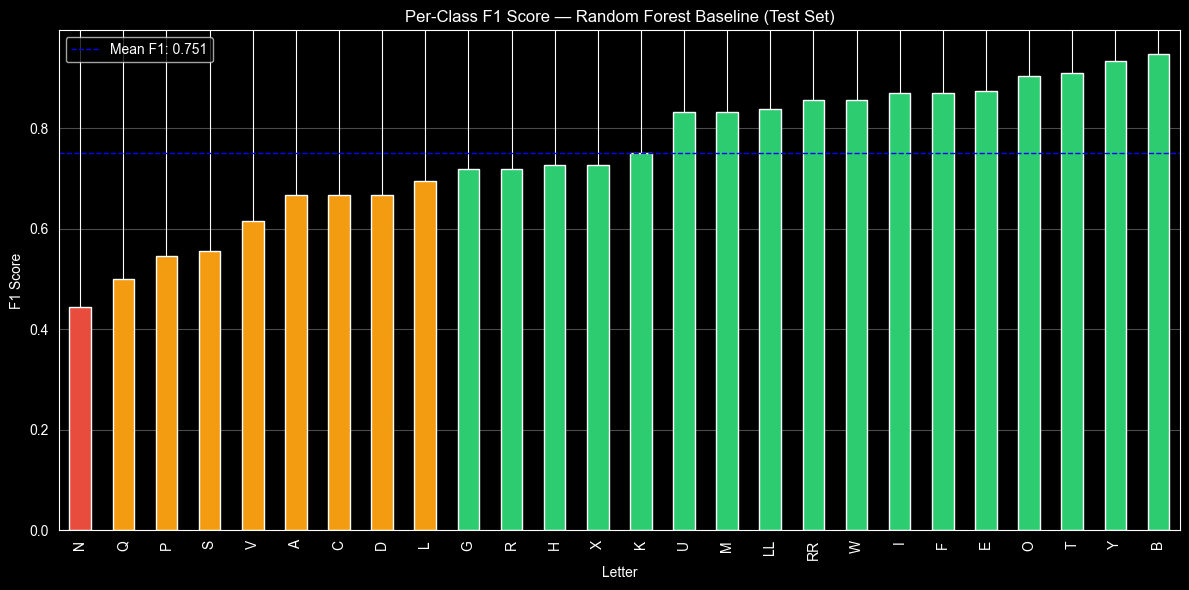


Easiest letters (highest F1):
  E: 0.875
  O: 0.903
  T: 0.909
  Y: 0.933
  B: 0.947

Hardest letters (lowest F1):
  N: 0.444
  Q: 0.500
  P: 0.545
  S: 0.556
  V: 0.615


In [12]:
# Per-class F1 scores to identify the hardest and easiest letters
from sklearn.metrics import f1_score as sk_f1

y_pred_test_rf = rf_model.predict(X_test)
per_class_f1 = sk_f1(y_test, y_pred_test_rf, average=None, labels=range(n_classes))
f1_by_letter = pd.Series(per_class_f1, index=class_names).sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#e74c3c" if v < 0.5 else "#f39c12" if v < 0.7 else "#2ecc71" for v in f1_by_letter.values]
f1_by_letter.plot(kind="bar", ax=ax, color=colors)
ax.set_title("Per-Class F1 Score — Random Forest Baseline (Test Set)")
ax.set_xlabel("Letter")
ax.set_ylabel("F1 Score")
ax.axhline(y=f1_by_letter.mean(), color="blue", linestyle="--", linewidth=1, label=f"Mean F1: {f1_by_letter.mean():.3f}")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nEasiest letters (highest F1):")
for letter, f1 in f1_by_letter.tail(5).items():
    print(f"  {letter}: {f1:.3f}")

print(f"\nHardest letters (lowest F1):")
for letter, f1 in f1_by_letter.head(5).items():
    print(f"  {letter}: {f1:.3f}")

## 8. Conclusions

### Question 1: ¿Qué algoritmo se puede utilizar como baseline?

**Random Forest (100 trees)** serves as the primary baseline. It is a strong choice because:
- It handles the high multicollinearity between adjacent landmarks naturally (unlike linear models).
- It requires minimal hyperparameter tuning out of the box.
- It provides interpretable feature importances.
- As a non-linear ensemble, it captures the complex geometric relationships between finger positions.

Logistic Regression serves as a simpler linear reference — its performance relative to Random Forest tells us how much non-linearity is needed for this problem.

### Question 2: ¿Se puede determinar la importancia de las características?

Yes. Random Forest's MDI-based feature importances reveal which landmarks and coordinates contribute the most to distinguishing between letters. Key findings:
- **Fingertip positions** (especially y-coordinates) are the most discriminative — they capture whether fingers are extended or curled.
- **Thumb landmarks** tend to have high importance since thumb position varies significantly across LSM letters.
- **Wrist coordinates** have near-zero importance (as expected, since we normalize by subtracting the wrist position).
- The high importance concentration in a subset of features suggests that **feature engineering** (inter-finger distances, joint angles) could further improve the model.

### Question 3: ¿El modelo está sub/sobreajustando?

The learning curves and train-vs-validation gap analysis reveal:
- **Random Forest** likely shows moderate overfitting — the train accuracy is near-perfect (≈100%) while the validation/test accuracy is lower. This is typical of Random Forests on small datasets and can be mitigated with regularization (max depth, min samples per leaf) or more training data.
- **Logistic Regression** may show slight underfitting — if its train and validation scores are both moderate, it indicates the linear model cannot fully capture the non-linear decision boundaries between letter classes.

### Question 4: ¿Cuál es la métrica adecuada?

- **Macro F1-score** is the primary metric — it weights all 26 letters equally, ensuring the model works well for every letter (not just the frequent ones). This is essential for a communication tool where every letter matters.
- **Accuracy** is reported alongside F1 as a complementary overall measure, valid because the classes are approximately balanced.

### Question 5: ¿Cuál debería ser el desempeño mínimo?

| Threshold | Value | Meaning |
|-----------|-------|---------|
| Random chance | ~3.8% | The floor — a model that learns nothing |
| Minimum acceptable | ≥ 50% | Proves the data contains discriminative signal |
| Baseline established | *See results above* | The Random Forest baseline sets the reference |
| Production target | ≥ 85% | Needed for a usable real-time LSM translation tool |

The baseline results demonstrate that **the MediaPipe keypoints contain substantial signal for letter classification**, validating the viability of this approach. The gap between the baseline and the production target defines the space for improvement through feature engineering, more data, and more complex architectures (e.g., the LSMTransformer already in this project).